# 06 — Evaluación, Estabilidad e Interpretación de Negocio
**Autor:** Persona 6 — Dúo C (Modelado, evaluación y estabilidad)
**Proyecto:** GeoRisk Finder — Riesgo Geológico Global

## Objetivo de este notebook

Este notebook **no vuelve a entrenar** K-Means ni DBSCAN desde cero: parte de los
resultados de clustering entregados por **Persona 5** (`05_modelado_kmeans_dbscan.ipynb`)
y responde a tres preguntas de negocio:

1. **¿Es fiable la partición en clusters, o es un artefacto del azar?**
   → Prueba de estabilidad con distintas semillas y distintos subconjuntos temporales.
2. **¿Qué significa cada cluster para alguien que no sabe de Machine Learning?**
   → Traducción de centroides/estadísticas a perfiles de riesgo en lenguaje de negocio.
3. **¿Cómo se ve esto aplicado a un país real?**
   → Casos de estudio: Japón, Chile, Venezuela y España.

> ⚠️ **Estado de este notebook:** ESQUELETO EN CONSTRUCCIÓN.
> Mientras Persona 5 termina el modelado definitivo, este notebook usa un
> **dataset sintético (dummy)** con la misma forma que el output esperado,
> para poder desarrollar y probar toda la lógica de estabilidad e interpretación
> sin quedar bloqueado. Cuando llegue `data/processed/celdas_clusters.csv`
> (o el nombre que acuerde el equipo), solo se cambia la celda de carga de datos.

## Estructura del notebook

| Sección | Contenido |
|---|---|
| 1 | Setup e imports |
| 2 | Carga de datos (dummy → real) |
| 3 | Prueba de estabilidad — semillas |
| 4 | Prueba de estabilidad — subconjuntos temporales |
| 5 | Síntesis de estabilidad (¿es fiable el modelo?) |
| 6 | Perfilado de clusters (estadísticas por variable) |
| 7 | Traducción a lenguaje de negocio |
| 8 | Casos de estudio (Japón, Chile, Venezuela, España) |
| 9 | Conclusiones finales |


## 1. Setup e imports

In [1]:
# Standard libraries
import numpy as np
import pandas as pd

# Modeling / evaluation
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Carga de datos

**Estado real del pipeline (actualizado):**

| Pieza | Estado | Responsable |
|---|---|---|
| `data/processed/grid_features.csv` (celda x features, SIN escalar/PCA) | ✅ Mergeado a `main` | Persona 3 |
| Preprocesamiento + PCA (`feature/preprocesamiento-pca`) | 🟡 En rama, aún sin mergear | Persona 4 |
| Clustering final (`cluster_kmeans`, `cluster_dbscan`) | ❌ Todavía no existe | Persona 5 |

**Input final esperado de Persona 5:**

| Qué necesito | Nombre de archivo sugerido | Columnas mínimas |
|---|---|---|
| Dataset celda x features + cluster asignado | `data/processed/celdas_clusters.csv` | `cell_id`, `lat`, `lon`, features tras PCA, `cluster_kmeans`, `cluster_dbscan` |
| Modelo entrenado (opcional pero útil) | `outputs/models/kmeans_final.joblib` | — |
| K elegido y métricas de referencia | Markdown/README de Persona 5 | K óptimo, silhouette score, nº de features tras PCA |

**Mientras ese archivo no exista**, ya tenemos algo mejor que un dataset
inventado: el `grid_features.csv` **real** de Persona 3 (41.162 celdas, 15
columnas). No tiene PCA ni cluster todavía, así que aplicamos aquí una
**imputación y un escalado mínimos y explícitamente provisionales**, solo
para poder probar la lógica de estabilidad con datos reales. Esto **no
sustituye** el preprocesamiento oficial de Persona 4 — en cuanto su rama se
mergee, esta celda se borra y se usa directamente su output.


In [2]:
DATA_PATH_REAL = "../data/processed/grid_features.csv"  # output real de Persona 3
DATA_PATH_FINAL = "../data/processed/celdas_clusters.csv"  # TODO: output final de Persona 5 (aun no existe)

FEATURE_COLS = [
    "eq_count", "eq_mag_mean", "eq_mag_max", "eq_depth_mean", "eq_energy_log",
    "cyclone_count", "wind_mean", "wind_max", "pressure_min_mean",
    "dist_nearest_volcano_km", "volcano_count",
]


def load_provisional_dataset(path: str = DATA_PATH_REAL, n_clusters: int = 5, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    """Load Persona 3's real grid_features.csv and add a PROVISIONAL cluster
    label, computed locally with a plain KMeans over mean-imputed + scaled
    features.

    This is NOT the official model. It exists only so the stability and
    business-interpretation logic in this notebook can be developed and
    tested against real feature distributions, instead of synthetic data.
    Once Persona 4 (PCA) and Persona 5 (K-Means/DBSCAN) merge their branches,
    this function is replaced by a simple pd.read_csv(DATA_PATH_FINAL).
    """
    raw = pd.read_csv(path)

    # NaN meaning here (per Persona 3's notebook): a hazard-intensity column
    # is NaN when that hazard's count is 0 for the cell (no events), not a
    # missing measurement. Mean-imputation is a provisional stand-in for
    # Persona 4's official strategy, not the final decision.
    X = raw[FEATURE_COLS].fillna(raw[FEATURE_COLS].mean())
    X_scaled = StandardScaler().fit_transform(X)

    provisional_model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    raw["cluster_kmeans"] = provisional_model.fit_predict(X_scaled)
    return raw


try:
    df = load_provisional_dataset()
    print(f"Loaded REAL data from Persona 3: {df.shape[0]} cells, provisional K={df['cluster_kmeans'].nunique()}")
except FileNotFoundError:
    print("grid_features.csv not found at expected path -> check you are running from notebooks/")

df.head()


Loaded REAL data from Persona 3: 41162 cells, provisional K=5


,cell_id,lat,lon,eq_count,eq_mag_mean,eq_mag_max,eq_depth_mean,eq_energy_log,eq_days_since_last_major,cyclone_count,wind_mean,wind_max,pressure_min_mean,dist_nearest_volcano_km,volcano_count,cluster_kmeans
0,830d83fffffffff,66.541996,-175.333902,3.0,5.00,5.3,9.766667,12.905037,NaN,0.0,NaN,NaN,NaN,9133.832542,0,1
1,832969fffffffff,34.792390,-136.442913,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,7098.227049,0,1
2,83722efffffffff,6.739360,138.817498,0.0,NaN,NaN,NaN,NaN,NaN,94.0,36.630435,50.0,1002.902597,1330.522393,0,3
3,8314b1fffffffff,48.255967,125.684028,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1797.757383,0,1
4,836803fffffffff,6.893151,117.880300,2.0,5.25,5.4,42.000000,13.031879,NaN,5.0,35.000000,35.0,1004.500000,702.621529,0,3


## 3. Prueba de estabilidad — distintas semillas

**Objetivo:** comprobar que si re-ejecuto K-Means cambiando solo la semilla
aleatoria (`random_state`), obtengo particiones *equivalentes*, no clusters
completamente distintos.

**Fundamento:** K-Means depende de la inicialización de los centroides.
Si el modelo es "de verdad", debería converger a soluciones parecidas sin
importar la semilla. Si cambia mucho, la estructura de clusters es débil
o el K elegido no es el adecuado.

**Métrica:** *Adjusted Rand Index* (ARI) entre pares de particiones.
ARI = 1 → particiones idénticas. ARI ≈ 0 → equivalente a asignar clusters al azar.


In [3]:
K_OPTIMO = df["cluster_kmeans"].nunique()  # TODO: usar el K que reporte Persona 5 (aqui: el provisional)

def run_kmeans_with_seed(data: pd.DataFrame, k: int, seed: int) -> np.ndarray:
    """Fit KMeans on FEATURE_COLS with a given random seed and return labels.
    NaNs are mean-imputed (same provisional strategy as load_provisional_dataset)
    since Persona 4's official preprocessing is not merged yet.
    """
    X = data[FEATURE_COLS].fillna(data[FEATURE_COLS].mean())
    X_scaled = StandardScaler().fit_transform(X)
    model = KMeans(n_clusters=k, random_state=seed, n_init=10)
    return model.fit_predict(X_scaled)


SEEDS = [0, 1, 7, 21, 42, 99]
seed_labels = {seed: run_kmeans_with_seed(df, K_OPTIMO, seed) for seed in SEEDS}

# Pairwise ARI matrix between every pair of seeds
ari_matrix = pd.DataFrame(index=SEEDS, columns=SEEDS, dtype=float)
for s1 in SEEDS:
    for s2 in SEEDS:
        ari_matrix.loc[s1, s2] = adjusted_rand_score(seed_labels[s1], seed_labels[s2])

ari_matrix


,0,1,7,21,42,99
0,1.000000,0.663475,0.663241,0.999556,0.665079,0.665543
1,0.663475,1.000000,0.999003,0.663544,0.996351,0.996946
7,0.663241,0.999003,1.000000,0.663310,0.995538,0.996133
21,0.999556,0.663544,0.663310,1.000000,0.665149,0.665613
42,0.665079,0.996351,0.995538,0.665149,1.000000,0.999404
99,0.665543,0.996946,0.996133,0.665613,0.999404,1.000000


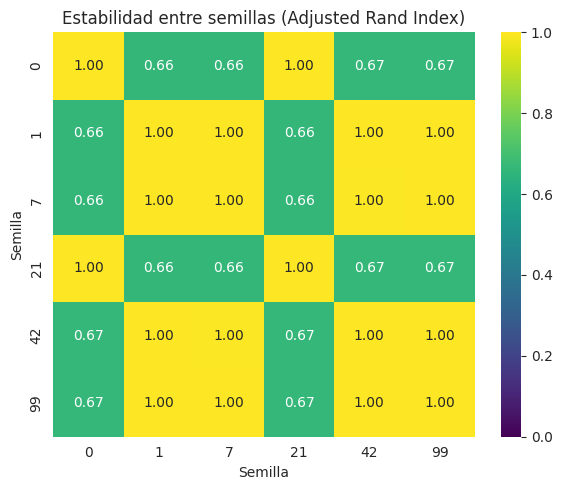

In [4]:
plt.figure(figsize=(6, 5))
sns.heatmap(ari_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title("Estabilidad entre semillas (Adjusted Rand Index)")
plt.xlabel("Semilla")
plt.ylabel("Semilla")
plt.tight_layout()
plt.show()


**TODO — interpretación (completar cuando tengamos el dataset real):**
- ¿El ARI promedio fuera de la diagonal es alto (>0.8), moderado (0.5–0.8) o bajo (<0.5)?
- ¿Hay algún par de semillas con ARI mucho más bajo que el resto? ¿Por qué podría pasar?
- Redactar una conclusión de 3-4 líneas, en lenguaje claro, sobre si el modelo es estable frente a la semilla.


## 4. Prueba de estabilidad — subconjuntos temporales

**Objetivo:** comprobar que los clusters no dependen de "qué años concretos"
entraron en el dataset. Si entreno solo con eventos hasta 2015 y comparo con
el dataset completo, ¿la estructura de clusters se mantiene razonablemente?

> ⚠️ **Bloqueo real detectado (no un TODO cualquiera):** `grid_features.csv`
> de Persona 3 ya viene **agregado por celda** (conteos y medias), sin
> timestamp por celda — la fecha de cada evento individual se perdió al
> agregar. Con esta tabla **no se puede** hacer un corte temporal real.
>
> **Para hacer esta prueba de verdad necesito, de Persona 1/2/3:**
> - Los CSV de eventos individuales con fecha (`usgs_earthquakes_clean.csv`,
>   `ciclones_clean.csv` ya la tienen: columna de evento + timestamp).
> - O, más práctico: pedirle a Persona 3 que genere 2-3 versiones de
>   `grid_features.csv` con distintas ventanas temporales de agregación
>   (ej. hasta 2015 vs. histórico completo hasta 2025), igual que ya hace
>   con la ventana de sismos (1900-2025) y ciclones (1970-2025) — solo
>   habría que parametrizar el corte final en vez de dejarlo fijo.
>
> **Mientras tanto**, aquí simulamos una prueba de robustez *equivalente en
> espíritu* usando **subconjuntos aleatorios de celdas** (bootstrap-like):
> si el clustering es estable, debería sobrevivir también a "ver menos datos",
> no solo a cambiar la semilla. No es lo mismo que un corte temporal real,
> y se documenta así explícitamente para no confundir a quien lea el notebook.


In [5]:
def random_subset(data: pd.DataFrame, fraction: float, seed: int = RANDOM_STATE) -> pd.DataFrame:
    """Return a random subset of the cells, used as a stand-in for a real
    temporal cutoff until per-cell timestamps or multiple time-windowed
    versions of grid_features.csv are available (see markdown above).
    """
    return data.sample(frac=fraction, random_state=seed).copy()


FRACTIONS = [0.7, 0.85, 1.0]
subset_labels = {}

for frac in FRACTIONS:
    subset = random_subset(df, frac)
    labels = run_kmeans_with_seed(subset, K_OPTIMO, seed=RANDOM_STATE)
    subset_labels[frac] = pd.Series(labels, index=subset["cell_id"])

# Compare each partial subset against the full dataset, on the shared cells
full_labels = subset_labels[1.0]
subset_ari = {}
for frac in FRACTIONS[:-1]:
    shared_cells = subset_labels[frac].index.intersection(full_labels.index)
    subset_ari[frac] = adjusted_rand_score(
        subset_labels[frac].loc[shared_cells], full_labels.loc[shared_cells]
    )

subset_ari


{0.7: 0.37002278012862544, 0.85: 0.37141942819153867}

**TODO — interpretación:**
- ¿El ARI se mantiene alto al usar solo el 70% u 85% de las celdas?
- Cuando llegue una ventana temporal real, repetir esta sección sustituyendo
  `random_subset` por un corte por fecha, y comparar si el resultado cambia
  mucho respecto al proxy aleatorio (sería una señal interesante para el
  informe: la inestabilidad temporal es distinta de la inestabilidad por
  tamaño de muestra).


## 5. Síntesis de estabilidad

Tabla resumen que combina ambas pruebas (semillas + temporal) en un único
veredicto, para poder defenderlo frente al profesor sin repetir todo el análisis.

**TODO:** construir tabla `criterio | métrica obtenida | umbral de referencia | conclusión` y
redactar el veredicto final: **estable / parcialmente estable / inestable**, con justificación.


In [6]:
# TODO(Persona 6): construir la tabla resumen final aquí, ej.
# resumen_estabilidad = pd.DataFrame({
#     "criterio": ["Semillas (ARI medio)", "Subconjunto 70%", "Subconjunto 85%"],
#     "valor_obtenido": [ari_matrix.values[np.triu_indices_from(ari_matrix, k=1)].mean(),
#                         temporal_ari[0.7], temporal_ari[0.85]],
#     "umbral_referencia": [0.8, 0.8, 0.8],
# })
# resumen_estabilidad


## 6. Perfilado de clusters (estadísticas por variable)

Antes de "interpretar" un cluster hay que describirlo con datos: media/mediana
de cada feature por cluster, tamaño relativo, y algún gráfico (radar o barras)
que lo haga visual.


In [7]:
cluster_profile = df.groupby("cluster_kmeans")[FEATURE_COLS].agg(["mean", "median", "std"])
cluster_profile["size"] = df.groupby("cluster_kmeans").size()
cluster_profile


eq_count                    eq_mag_mean                      \
                      mean median         std        mean    median       std   
cluster_kmeans                                                                  
0                25.447784    1.0  306.339557    4.567503  4.650000  0.533781   
1                 1.675960    0.0    9.182739    5.088416  4.997383  0.310731   
2               130.893004   45.0  758.748870    5.186164  5.022538  0.474060   
3                 3.209418    0.0   22.270490    5.062611  4.965857  0.397871   
4                 5.462321    0.0   26.586117    5.018009  4.933035  0.341780   

               eq_mag_max                  eq_depth_mean  ...  \
                     mean median       std          mean  ...   
cluster_kmeans                                            ...   
0                4.727603  4.700  0.281646     19.571293  ...   
1                5.728388  5.700  0.373897     26.874306  ...   
2                7.000489  6.925  0.546841     87.876336  ...   
3                5.698930  5.700  0.535936     24.894523  ...   
4                5.726872  5.710  0.670996     40.574797  ...   

               pressure_min_mean                          \
                            mean       median        std   
cluster_kmeans                                             
0                     993.669199   994.166667   8.044134   
1                     991.064150   991.346154   6.784647   
2                     989.997214   990.220024   8.741645   
3                    1000.979116  1001.166667   5.445335   
4                     983.406380   985.236111  10.204378   

               dist_nearest_volcano_km                            \
                                  mean       median          std   
cluster_kmeans                                                     
0                          4330.216711  3370.924266  3204.103488   
1                          5213.869483  4813.716120  3030.034646   
2                          3923.418936  2482.503715  3617.441841   
3                          3583.632059  2809.107836  2585.155160   
4                          3914.990446  2645.270799  3161.892976   

               volcano_count               size  
                        mean median  std         
cluster_kmeans                                   
0                        0.0    0.0  0.0   2595  
1                        0.0    0.0  0.0  27654  
2                        0.0    0.0  0.0   1944  
3                        0.0    0.0  0.0   4842  
4                        0.0    0.0  0.0   4127  

[5 rows x 34 columns]

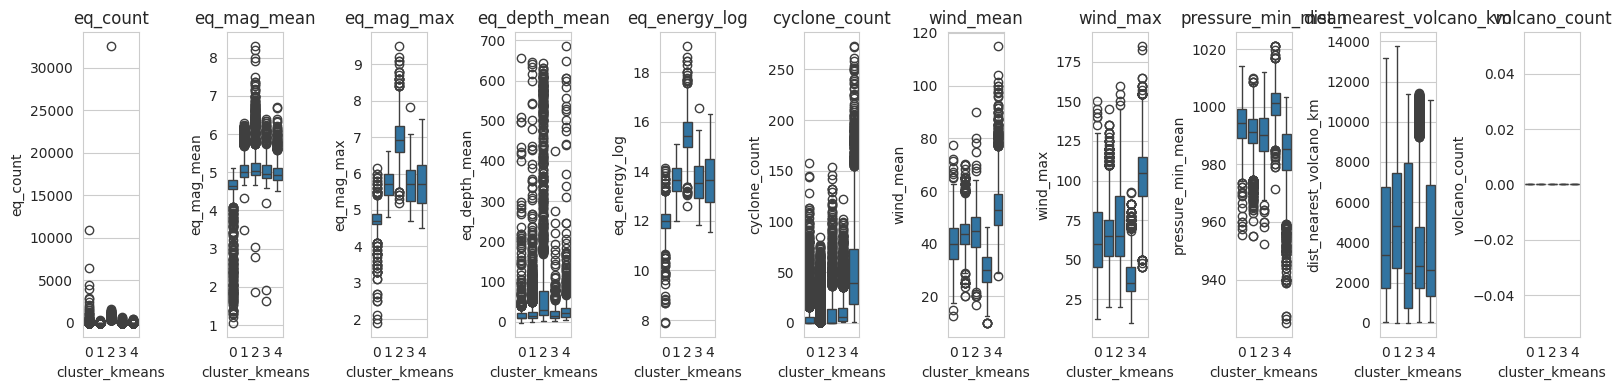

In [8]:
fig, axes = plt.subplots(1, len(FEATURE_COLS), figsize=(16, 4), sharey=False)
for ax, col in zip(axes, FEATURE_COLS):
    sns.boxplot(data=df, x="cluster_kmeans", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 7. Traducción a lenguaje de negocio

Aquí es donde el número de cluster deja de ser `cluster_kmeans == 2` y pasa a
ser algo que una aseguradora, un gobierno local o un urbanista pueda usar.

**Plantilla por cluster** (rellenar una fila por cada cluster obtenido):

| Cluster | Nombre de negocio | Perfil técnico (resumen) | Nivel de riesgo | Recomendación / implicación de negocio |
|---|---|---|---|---|
| 0 | *(ej. "Riesgo sísmico alto, ciclónico bajo")* | *(freq sísmica alta, viento bajo, cerca de volcán)* | Alto | *(ej. prima de seguro tipo X, normativa de construcción anti-sísmica)* |
| 1 | | | | |
| 2 | | | | |
| 3 | | | | |

**TODO(Persona 6):** completar esta tabla usando los resultados reales de la
Sección 6, no inventar los valores. Cada fila debe poder justificarse con un
número concreto de `cluster_profile`.


In [9]:
# TODO: construir esta tabla programáticamente a partir de cluster_profile,
# y luego redactar a mano la columna "Nombre de negocio" / "Recomendación".

business_labels = {
    # 0: "Riesgo sísmico alto, ciclónico bajo",
    # 1: "...",
}


## 8. Casos de estudio: Japón, Chile, Venezuela, España

Para cada país:
1. Identificar qué celdas H3 caen dentro de ese país (join espacial con `lat`/`lon`).
2. Ver qué cluster(s) predominan.
3. Contrastar con el perfil de negocio de la Sección 7.
4. Redactar una conclusión corta orientada al Dúo de producto (para el pitch).

**TODO(Persona 6):** una subsección por país, con:
- Mapa o tabla de celdas del país por cluster.
- 1 gráfico de apoyo (ej. distribución de clusters dentro del país).
- 3-5 líneas de conclusión de negocio.


### Caso de estudio: Japón

**TODO:** completar con datos reales.

In [10]:
# TODO: filtrar celdas correspondientes a Japón y analizar distribución de clusters
# pais_df = df[...]
# pais_df["cluster_kmeans"].value_counts(normalize=True)


### Caso de estudio: Chile

**TODO:** completar con datos reales.

In [11]:
# TODO: filtrar celdas correspondientes a Chile y analizar distribución de clusters
# pais_df = df[...]
# pais_df["cluster_kmeans"].value_counts(normalize=True)


### Caso de estudio: Venezuela

**TODO:** completar con datos reales.

In [12]:
# TODO: filtrar celdas correspondientes a Venezuela y analizar distribución de clusters
# pais_df = df[...]
# pais_df["cluster_kmeans"].value_counts(normalize=True)


### Caso de estudio: España

**TODO:** completar con datos reales.

In [13]:
# TODO: filtrar celdas correspondientes a España y analizar distribución de clusters
# pais_df = df[...]
# pais_df["cluster_kmeans"].value_counts(normalize=True)


## 9. Conclusiones finales

**TODO(Persona 6):** resumen ejecutivo (10-15 líneas) que combine:
- Veredicto de estabilidad (Sección 5).
- Los perfiles de negocio más relevantes (Sección 7).
- Qué implica esto para el producto final (demo / pitch del Dúo A en su rotación).
